In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("E:\Python\Bicycle_Traffic_Flow_GNN\data\smartcameras_line--2025-01-01T03-01-00--2025-02-01T03-01-00--tud_project--y16mv1.csv")

for col in ["created_at", "start_time", "end_time"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

for col in ["count_in", "count_out"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# OPTIONAL: set your local timezone if needed (data looks naive)
df["start_time"] = df["start_time"].dt.tz_localize("UTC").dt.tz_convert("Europe/Amsterdam")

display(df.head())

,pkey_id,created_at,sensor_id,start_time,end_time,count_in,count_out,element_id,element_name
0,9401503,2025-03-01 03:02:00.755939,TUD_SBXN9A,2025-03-01 04:01:00+01:00,2025-03-01 03:02:00,0,0,2,Line 0
1,9401510,2025-03-01 03:02:00.961803,TUD_SBX26,2025-03-01 04:01:00+01:00,2025-03-01 03:02:00,0,0,2,Line 0
2,9401514,2025-03-01 03:02:01.057958,TUD_SBX26,2025-03-01 04:01:00+01:00,2025-03-01 03:02:00,0,0,2,Line 0
3,9401515,2025-03-01 03:02:01.057958,TUD_SBX26,2025-03-01 04:01:00+01:00,2025-03-01 03:02:00,0,0,1000,Line 2
4,9401516,2025-03-01 03:02:01.085150,TUD_SPX14,2025-03-01 04:01:00+01:00,2025-03-01 03:02:00,0,0,1001,Line 0


In [ ]:
SENSOR_ID = "TUD_SBX01"         # change this
DAY = "2025-01-12"              # change this (YYYY-MM-DD)

m = (
    (df["sensor_id"] == SENSOR_ID)
    & (df["start_time"].dt.date == pd.to_datetime(DAY).date())
)
d = df.loc[m].copy()

if d.empty:
    raise ValueError(f"No rows for sensor {SENSOR_ID!r} on {DAY}.")

In [11]:
# --- Aggregate ---
d = d.set_index('start_time')
per_min = d[['count_in', 'count_out']].groupby('start_time').sum()
per_5min = per_min.resample('5T').sum()
per_15min = per_min.resample('15T').sum()

C:\Temp\Raf\ipykernel_15896\449446259.py:4: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  per_5min = per_min.resample('5T').sum()
C:\Temp\Raf\ipykernel_15896\449446259.py:5: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  per_15min = per_min.resample('15T').sum()


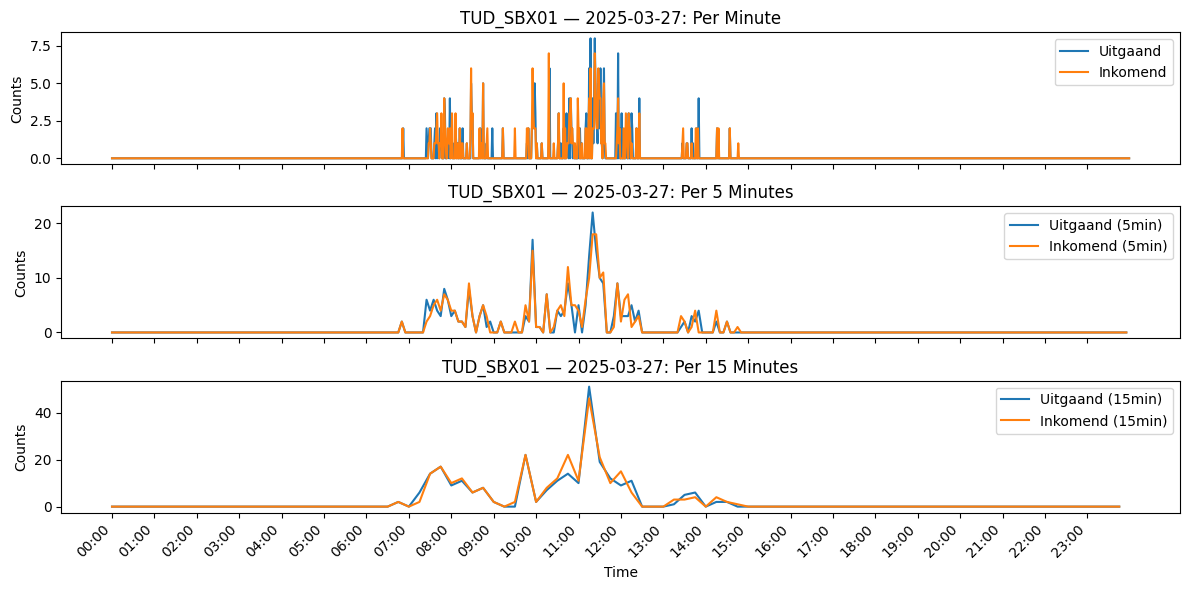

In [12]:
# --- Two plots: per-minute vs per-5-min ---
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

# Per-minute
axes[0].plot(per_min.index, per_min['count_in'], label="Uitgaand")
axes[0].plot(per_min.index, per_min['count_out'], label="Inkomend")
axes[0].set_title(f"{SENSOR_ID} — {DAY}: Per Minute")
axes[0].set_ylabel("Counts")
axes[0].legend()

# Per-5-minute
axes[1].plot(per_5min.index, per_5min['count_in'], label="Uitgaand (5min)")
axes[1].plot(per_5min.index, per_5min['count_out'], label="Inkomend (5min)")
axes[1].set_title(f"{SENSOR_ID} — {DAY}: Per 5 Minutes")
axes[1].set_ylabel("Counts")
axes[1].legend()

# Per-15-minute
axes[2].plot(per_15min.index, per_15min['count_in'], label="Uitgaand (15min)")
axes[2].plot(per_15min.index, per_15min['count_out'], label="Inkomend (15min)")
axes[2].set_title(f"{SENSOR_ID} — {DAY}: Per 15 Minutes")
axes[2].set_ylabel("Counts")
axes[2].set_xlabel("Time")
axes[2].legend()


# --- Format x-axis without mdates ---
# Use pandas' built-in formatter via index.strftime
axes[2].set_xticks(per_15min.index[::4])   # show every ~hour (12*5min = 60min)
axes[2].set_xticklabels(per_15min.index[::4].strftime("%H:%M"), rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [13]:
SENSOR_ID_2 = "TUD_SBX01"         # change this
DAY_2 = "2025-01-13"              # change this (YYYY-MM-DD)

m2 = (
    (df["sensor_id"] == SENSOR_ID_2)
    & (df["start_time"].dt.date == pd.to_datetime(DAY_2).date())
)
d2 = df.loc[m2].copy()

if d2.empty:
    raise ValueError(f"No rows for sensor {SENSOR_ID_2!r} on {DAY_2}.")

# --- Aggregate ---
d2 = d2.set_index('start_time')
per_min2 = d2[['count_in', 'count_out']].groupby('start_time').sum()
per_5min2 = per_min2.resample('5T').sum()
per_15min2 = per_min2.resample('15T').sum()

ValueError: No rows for sensor 'TUD_SBX01' on 2025-01-13.

NameError: name 'per_5min2' is not defined

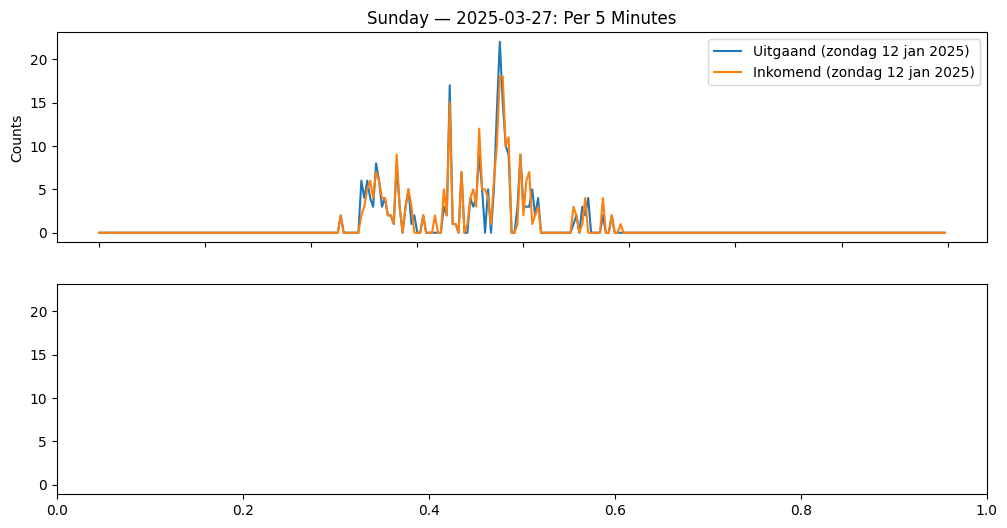

In [14]:
# --- Two plots: per-minute vs per-5-min ---
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharey=True)

# Per-5-minute
axes[0].plot(per_5min.index, per_5min['count_in'], label="Uitgaand (zondag 12 jan 2025)")
axes[0].plot(per_5min.index, per_5min['count_out'], label="Inkomend (zondag 12 jan 2025)")
axes[0].set_title(f"Sunday — {DAY}: Per 5 Minutes")
axes[0].set_ylabel("Counts")
# axes[0].set_xlabel("Time")
axes[0].tick_params(labelbottom=False)  # hides only the labels, keeps the ticks
axes[0].legend()

# Per-15-minute
axes[1].plot(per_5min2.index, per_5min2['count_in'], label="Uitgaand (maandag 13 jan 2025)")
axes[1].plot(per_5min2.index, per_5min2['count_out'], label="Inkomend (maandag 13 jan 2025)")
axes[1].set_title(f"Monday — {DAY_2}: Per 5 Minutes")
axes[1].set_ylabel("Counts")
axes[1].set_xlabel("Time")
axes[1].legend()


# --- Format x-axis without mdates ---
# Use pandas' built-in formatter via index.strftime
# axes[0].set_xticks(per_5min.index[::12])   # show every ~hour (12*5min = 60min)
# axes[0].set_xticklabels(per_5min.index[::12].strftime("%H:%M"), rotation=45, ha="right")
axes[1].set_xticks(per_5min2.index[::12])   # show every ~hour (12*5min = 60min)
axes[1].set_xticklabels(per_5min2.index[::12].strftime("%H:%M"), rotation=45, ha="right")

plt.tight_layout()
plt.show()